# 02 - M4 (4 clases, compuestos con una sola etiqueta)

Clasificación multiclase con los 12 modelos repetida `N_RUNS` veces (10 por defecto) con splits distintos (tuning con GridSearchCV en la primera corrida), test de Wilcoxon, análisis SHAP y clasificación con las 10 features más importantes.

In [1]:
from functools import partial

import pandas as pd

from csp_perovskites import config, io, plotting, preprocessing as pp
from csp_perovskites import datasets as ds, evaluation as ev, models, shap_analysis as sa

## Parámetros

In [2]:
N_RUNS = config.N_RUNS
CV = config.CV_FOLDS
SCALER = "minmax"          # "minmax" (paper), "standard" o None
MODELS = None              # None = los 12 modelos; o una lista de nombres
SHAP_MAX_SAMPLES = None    # submuestreo del test para acelerar SHAP

split_fn = ds.make_m4_split
df = pp.clean_master(io.load_master())
df_decor, _ = pp.decorrelate(df)

## Clasificación con todas las features

In [3]:
full = ev.run_repeated(df_decor, split_fn, models.get_classifiers(MODELS),
                       n_runs=N_RUNS, cv=CV, scaler=SCALER)
summary = ev.summarize(full.runs)
io.save_table(full.runs, "M4_runs.csv")
io.save_table(summary, "M4_summary.csv", index=True)
io.save_table(pd.DataFrame({m: [p] for m, p in full.best_params.items()}).T.rename(columns={0: "best_params"}),
              "M4_best_params.csv", index=True)
ev.summarize(full.runs, as_text=True)

Run 1/10 (seed=42)


/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:493: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/isabel/CSP_Perovskites/.venv/lib/python3.1

  Logistic Regression      acc=0.4784  f1=0.3593  auc=0.7473  (24.2s)
  Naive Bayes              acc=0.3885  f1=0.2865  auc=0.6790  (0.0s)
  K-Nearest Neighbors      acc=0.7159  f1=0.5174  auc=0.7871  (2.6s)
  Decision Tree            acc=0.7469  f1=0.5267  auc=0.7242  (6.9s)
  Random Forest            acc=0.8246  f1=0.6179  auc=0.9219  (249.6s)
  Extra Trees              acc=0.8235  f1=0.6135  auc=0.9139  (24.8s)
  AdaBoost                 acc=0.6193  f1=0.4655  auc=0.8313  (64.7s)
  Gradient Boosting        acc=0.8135  f1=0.6116  auc=0.9093  (511.8s)
  XGBoost                  acc=0.8002  f1=0.6080  auc=0.8967  (21.9s)
  LightGBM                 acc=0.8357  f1=0.6135  auc=0.9055  (32.1s)


/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `pr

  Support Vector Machine   acc=0.7103  f1=0.5253  auc=0.8698  (263.9s)
  Neural Network           acc=0.7758  f1=0.5499  auc=0.8539  (386.9s)
Run 2/10 (seed=43)
  Logistic Regression      acc=0.4606  f1=0.3483  auc=0.7532  (6.0s)
  Naive Bayes              acc=0.3629  f1=0.2765  auc=0.6991  (0.0s)
  K-Nearest Neighbors      acc=0.7159  f1=0.4815  auc=0.7726  (0.0s)
  Decision Tree            acc=0.7358  f1=0.5160  auc=0.7032  (0.3s)
  Random Forest            acc=0.8280  f1=0.6484  auc=0.9041  (17.2s)
  Extra Trees              acc=0.8346  f1=0.6049  auc=0.9106  (7.1s)
  AdaBoost                 acc=0.6404  f1=0.4662  auc=0.7926  (13.3s)
  Gradient Boosting        acc=0.8080  f1=0.5855  auc=0.8900  (60.8s)
  XGBoost                  acc=0.7925  f1=0.5566  auc=0.8729  (1.4s)
  LightGBM                 acc=0.8324  f1=0.6105  auc=0.8948  (2.8s)


...

/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Support Vector Machine   acc=0.7114  f1=0.5063  auc=0.8569  (16.0s)
  Neural Network           acc=0.7802  f1=0.5479  auc=0.8592  (34.8s)
Run 10/10 (seed=51)
  Logistic Regression      acc=0.4650  f1=0.3439  auc=0.7425  (4.5s)
  Naive Bayes              acc=0.4018  f1=0.2907  auc=0.7243  (0.0s)
  K-Nearest Neighbors      acc=0.7414  f1=0.5279  auc=0.7957  (0.0s)
  Decision Tree            acc=0.7392  f1=0.4908  auc=0.6958  (0.3s)
  Random Forest            acc=0.8346  f1=0.6656  auc=0.9180  (17.4s)
  Extra Trees              acc=0.8269  f1=0.6054  auc=0.9149  (4.6s)
  AdaBoost                 acc=0.6360  f1=0.4582  auc=0.7996  (15.3s)
  Gradient Boosting        acc=0.8158  f1=0.6129  auc=0.8967  (70.0s)
  XGBoost                  acc=0.8036  f1=0.6150  auc=0.8887  (1.9s)
  LightGBM                 acc=0.8391  f1=0.6448  auc=0.9136  (3.6s)


/home/isabel/CSP_Perovskites/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Support Vector Machine   acc=0.7125  f1=0.5088  auc=0.8633  (18.6s)
  Neural Network           acc=0.7769  f1=0.5564  auc=0.8739  (37.4s)


,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,fit_time,predict_time
model,,,,,,,
LightGBM,0.8395 ± 0.0096,0.6348 ± 0.0224,0.6846 ± 0.0359,0.6077 ± 0.0243,0.9087 ± 0.0109,6.2752 ± 9.0958,0.1632 ± 0.0273
Random Forest,0.8393 ± 0.0125,0.6509 ± 0.0181,0.6820 ± 0.0335,0.6311 ± 0.0137,0.9163 ± 0.0114,40.8109 ± 73.3625,0.3218 ± 0.0613
Extra Trees,0.8371 ± 0.0133,0.6306 ± 0.0315,0.6770 ± 0.0415,0.6031 ± 0.0307,0.9136 ± 0.0113,8.2147 ± 7.1179,0.2418 ± 0.0721
Gradient Boosting,0.8173 ± 0.0072,0.6161 ± 0.0195,0.6181 ± 0.0212,0.6168 ± 0.0241,0.9002 ± 0.0107,109.5783 ± 141.4096,0.0469 ± 0.0249
XGBoost,0.8011 ± 0.0099,0.6073 ± 0.0203,0.5910 ± 0.0223,0.6330 ± 0.0260,0.8927 ± 0.0111,4.1231 ± 6.4879,0.0228 ± 0.0114
Neural Network,0.7845 ± 0.0144,0.5625 ± 0.0225,0.5566 ± 0.0221,0.5782 ± 0.0318,0.8733 ± 0.0166,70.0895 ± 111.5279,0.0135 ± 0.0057
Decision Tree,0.7441 ± 0.0119,0.5124 ± 0.0209,0.4981 ± 0.0177,0.5346 ± 0.0291,0.7087 ± 0.0139,0.9882 ± 2.0877,0.0060 ± 0.0014
K-Nearest Neighbors,0.7343 ± 0.0125,0.5236 ± 0.0254,0.4957 ± 0.0197,0.5862 ± 0.0399,0.7941 ± 0.0178,0.2734 ± 0.8133,0.1161 ± 0.0423
Support Vector Machine,0.7233 ± 0.0141,0.5379 ± 0.0269,0.5032 ± 0.0209,0.6295 ± 0.0444,0.8697 ± 0.0136,42.1969 ± 77.9370,0.7572 ± 0.2050


## Test de Wilcoxon entre los mejores modelos

In [4]:
top = [m for m in config.TOP_MODELS if m in full.best_params]
ev.wilcoxon_pairwise(full.runs, top, metric="accuracy")

,model_a,model_b,W,p_value
0,Random Forest,Extra Trees,13.5,0.320312
1,Random Forest,LightGBM,23.0,0.687500
2,Extra Trees,LightGBM,21.5,0.572266


## SHAP (Random Forest, Extra Trees, LightGBM)

Random Forest    acc=0.8202  (75.8s)
Extra Trees      acc=0.8280  (183.4s)
LightGBM         acc=0.8280  (2.5s)
Top-10 SHAP:   ['MPR_A', 'ARR_B', 'ARR_A', 'END_A', 't', 'END_B', 'r_A12', 'OF', 'BP_A', 'MPR_B']
Top-10 paper:  ['MPR_A', 'OF', 'ARR_B', 't', 'r_A12', 'END_A', 'END_B', 'ARR_A', 'BP_A', 'VR_A']


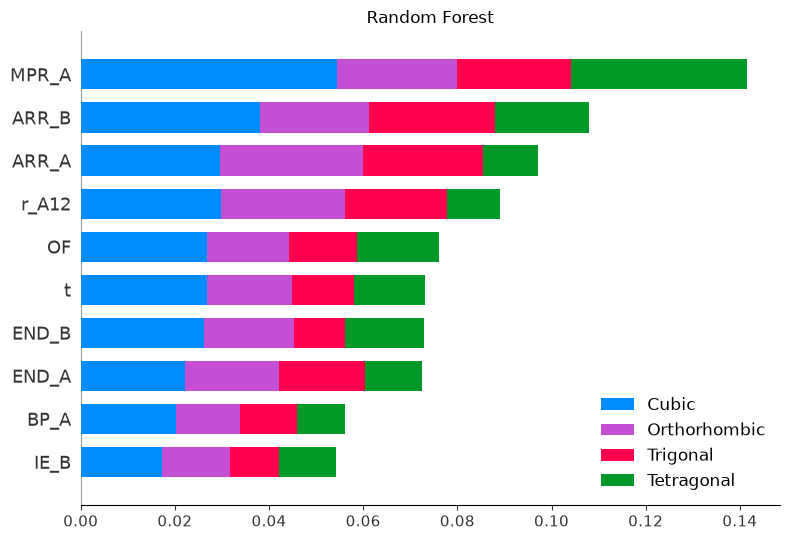

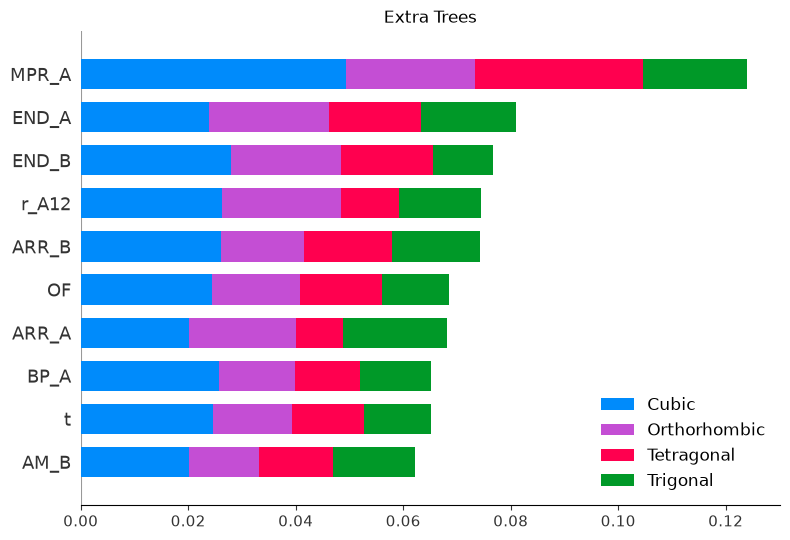

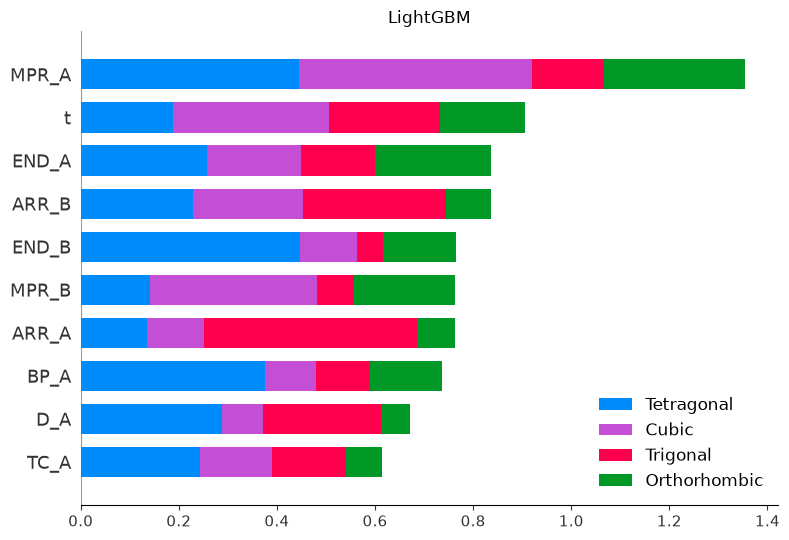

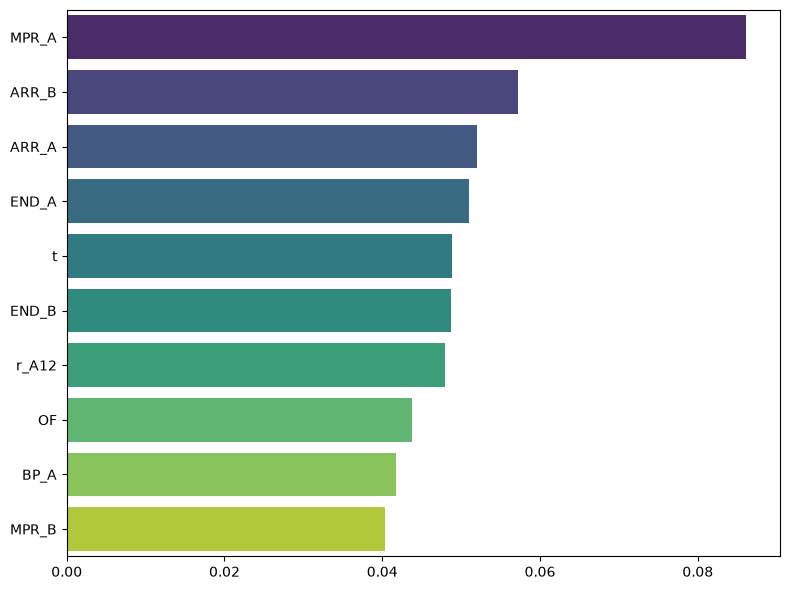

In [5]:
shap_results = sa.explain_models(split_fn(df_decor, seed=config.RANDOM_STATE), max_samples=SHAP_MAX_SAMPLES)
for model_name, result in shap_results.items():
    fig = sa.plot_shap_summary(result, top_k=10, title=model_name)
    io.save_fig(fig, f"M4_{model_name.replace(' ', '')}_shap_top10.png", directory=config.SHAP_DIR)

combined = sa.combine_importances(shap_results, normalize=True)
io.save_csv(combined, config.SHAP_DIR / "Combined_SHAP_importance_M4.csv")
fig = plotting.top_features_bar(combined, k=10)
io.save_fig(fig, "top10_features_M4.png")

shap_top10 = sa.top_k_features(combined, k=10)
print("Top-10 SHAP:  ", shap_top10)
print("Top-10 paper: ", config.TOP10_M4)

## Clasificación con features reducidas (M4*)

Por defecto se usa la lista del paper (`config.TOP10_M4`); cambia a `shap_top10` para usar la calculada arriba.

In [6]:
REDUCED_FEATURES = config.TOP10_M4

reduced = ev.run_repeated(df_decor, partial(split_fn, features=REDUCED_FEATURES),
                          models.get_classifiers(config.TOP_MODELS), n_runs=N_RUNS, cv=CV, scaler=SCALER)
io.save_table(reduced.runs, "M4_reduced_runs.csv")

cols = ["accuracy_mean", "accuracy_std", "fit_time_mean", "predict_time_mean"]
comparison = pd.concat({"M4": summary.loc[config.TOP_MODELS, cols],
                        "M4*": ev.summarize(reduced.runs).loc[config.TOP_MODELS, cols]}, axis=1)
io.save_table(comparison, "M4_vs_reduced.csv", index=True)
comparison

Run 1/10 (seed=42)
  Random Forest            acc=0.7780  f1=0.5414  auc=0.8929  (193.0s)
  Extra Trees              acc=0.7569  f1=0.5262  auc=0.8752  (26.1s)
  LightGBM                 acc=0.8269  f1=0.6127  auc=0.9015  (14.8s)
Run 2/10 (seed=43)
  Random Forest            acc=0.7825  f1=0.5582  auc=0.8572  (12.3s)
  Extra Trees              acc=0.7547  f1=0.5248  auc=0.8553  (9.4s)
  LightGBM                 acc=0.8002  f1=0.5650  auc=0.8832  (1.8s)
Run 3/10 (seed=44)
  Random Forest            acc=0.7614  f1=0.5405  auc=0.8867  (10.9s)
  Extra Trees              acc=0.7492  f1=0.5193  auc=0.8561  (4.1s)
  LightGBM                 acc=0.8169  f1=0.6045  auc=0.8945  (1.7s)
Run 4/10 (seed=45)
  Random Forest            acc=0.7936  f1=0.5660  auc=0.8841  (12.5s)
  Extra Trees              acc=0.7647  f1=0.5437  auc=0.8716  (3.5s)
  LightGBM                 acc=0.8135  f1=0.5737  auc=0.8972  (1.7s)
Run 5/10 (seed=46)
  Random Forest            acc=0.7869  f1=0.5686  auc=0.8841  (10.9s)


M4                                               \
              accuracy_mean accuracy_std fit_time_mean predict_time_mean   
model                                                                      
Random Forest      0.839290     0.012467     40.810912          0.321845   
Extra Trees        0.837070     0.013316      8.214675          0.241813   
LightGBM           0.839512     0.009593      6.275250          0.163174   

                        M4*                                               
              accuracy_mean accuracy_std fit_time_mean predict_time_mean  
model                                                                     
Random Forest      0.778912     0.016385     29.062267          0.301071  
Extra Trees        0.756937     0.019138      6.294120          0.248261  
LightGBM           0.815649     0.015141      2.971179          0.150832